## Rebuttal reliability figure

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

In [40]:
derivatives_folder = Path("../derivatives")

df_snr = pd.read_parquet(derivatives_folder / "revision_2/snr_stats_joined.parquet")
df_is = pd.read_parquet(derivatives_folder / "nsd/rsa_subject_subject_alignment_shift_1_joined.parquet")
tsnr = pd.read_parquet(derivatives_folder /"revision_2/tsnr_stats_all.parquet")

df_is = df_is.query("roi_x == roi_y and subject_i != subject_j")
df_is = df_is.groupby(["roi_x"]).similarity.mean().reset_index()
df_is = df_is.rename(columns={"roi_x": "roi", "similarity": "is_rsa"})

df_snr = df_snr.groupby(["roi"]).aggregate({"mean_snr": "mean", "std_snr": "mean",
                                   "num_voxels": "mean"}).reset_index().merge(df_is)

hcp = pd.read_csv("../derivatives/metadata/hcp.csv")
hcp = hcp[["roi", "name", "mne_name", "area_id", "area_color", "area"]]

df_snr = df_snr.merge(hcp)


# roi -= 180 where roi > 180
tsnr.loc[tsnr.roi > 180, "roi"] -= 180
tsnr = tsnr.groupby("roi").aggregate({"mean_value": "mean", "num_voxels": "mean"}).reset_index()
tsnr.roi = tsnr.roi.astype(int)
tsnr = tsnr.rename(columns={"mean_value": "tSNR"})

df_snr = df_snr.merge(tsnr, on="roi")

df_snr


,roi,mean_snr,std_snr,num_voxels_x,is_rsa,name,mne_name,area_id,area_color,area,tSNR,num_voxels_y
0,1,0.261826,0.213591,19820.875,0.194511,V1,L_V1_ROI-lh,0,#1f77b4,Primary Visual,46.912331,9910.4375
1,2,0.416271,0.249579,1488.500,0.210775,MST,L_MST_ROI-lh,6,#2ca02c,MT+ Visual Areas,61.857086,744.2500
2,3,0.126335,0.092360,2140.625,0.012278,V6,L_V6_ROI-lh,5,#ff9896,Dorsal Visual,66.559135,1070.3125
3,4,0.258049,0.211068,14275.250,0.177940,V2,L_V2_ROI-lh,1,#aec7e8,Early Visual (V2-4),51.443386,7137.6250
4,5,0.276185,0.183286,10409.125,0.125448,V3,L_V3_ROI-lh,1,#aec7e8,Early Visual (V2-4),51.861732,5204.5625
...,...,...,...,...,...,...,...,...,...,...,...,...
175,176,0.096122,0.071532,2229.375,0.004292,STSva,L_STSva_ROI-lh,13,#f7b6d2,Auditory Association,52.659935,1114.6875
176,177,0.066361,0.051232,3685.750,0.001881,TE1m,L_TE1m_ROI-lh,4,#d62728,Lateral Temporal,41.474777,1842.8750
177,178,0.055921,0.049045,1437.375,0.000320,PI,L_PI_ROI-lh,14,#7f7f7f,Insula & Frontal Operculum,38.772404,718.6875
178,179,0.079469,0.052962,1822.250,0.001305,a32pr,L_a32pr_ROI-lh,18,#17becf,Anterior Cingulate & mPFC,55.991173,911.1250


In [29]:
palette = df_snr[["area", "area_color"]].drop_duplicates().set_index("area").area_color.to_dict()
hue_order = df_snr[["area", "area_id"]].drop_duplicates().sort_values("area_id").area.to_list()

## Plot NCSNR 

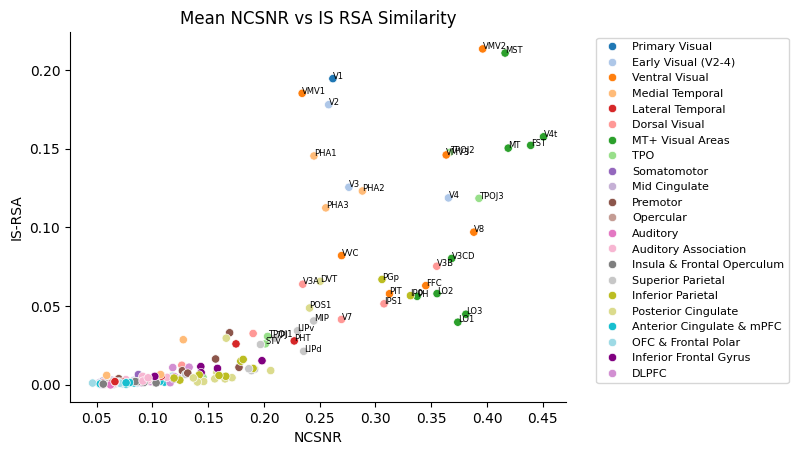

In [32]:
fig, ax = plt.subplots()

sns.scatterplot(data=df_snr, x="mean_snr", y="is_rsa", hue="area", ax=ax, palette=palette, hue_order=hue_order)
ax.set_title("Mean NCSNR vs IS RSA Similarity")

# Move legend outside the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Add test labels
for i, row in df_snr.iterrows():
    mean_snr = row["mean_snr"]
    is_rsa = row["is_rsa"]
    if mean_snr > 0.2 and is_rsa > 0.01:
        ax.text(mean_snr, is_rsa, row["name"], fontsize=6)

ax.set_xlabel("NCSNR")
ax.set_ylabel("IS-RSA")
sns.despine(ax=ax)

#fig.savefig("reliability_ncsnr_is_rsa.pdf", bbox_inches="tight", transparent=True)

Compute correlation

In [ ]:
r, p = stats.pearsonr(df_snr["mean_snr"], df_snr["is_rsa"])
print(f"NCSNR, all rois: Pearson r: {r:.3f}, p-value: {p:.4f}")

df_snr_subset = df_snr.sort_values("is_rsa", ascending=False).head(30)[["mean_snr", "is_rsa"]]
r, p = stats.pearsonr(df_snr_subset["mean_snr"], df_snr_subset["is_rsa"])
print(f"NCSNR, top 30 rois: Pearson r: {r:.3f}, p-value: {p:.4f}")

NCSNR, all rois: Pearson r: 0.817, p-value: 0.0000
NCSNR, top 30 rois: Pearson r: 0.241, p-value: 0.1995


## tSNR

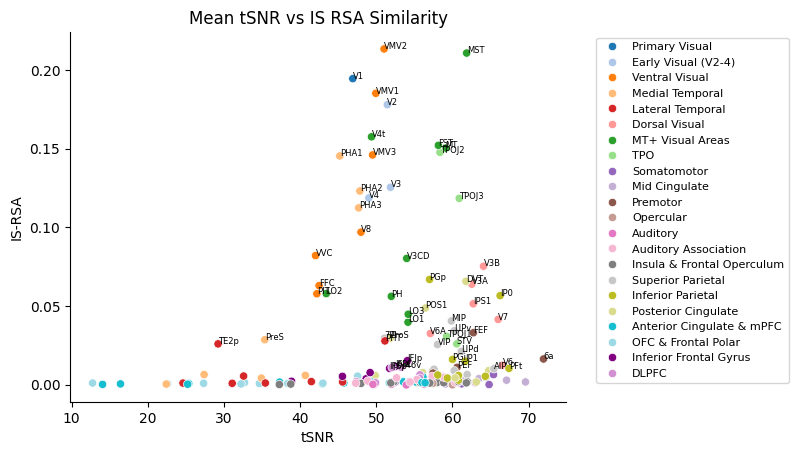

In [35]:
fig, ax = plt.subplots()

sns.scatterplot(data=df_snr, x="tSNR", y="is_rsa", hue="area", ax=ax, palette=palette, hue_order=hue_order)
ax.set_title("Mean tSNR vs IS RSA Similarity")

# Move legend outside the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Add test labels
for i, row in df_snr.iterrows():
    mean_snr = row["tSNR"]
    is_rsa = row["is_rsa"]
    if mean_snr > 0.2 and is_rsa > 0.01:
        ax.text(mean_snr, is_rsa, row["name"], fontsize=6)

ax.set_xlabel("tSNR")
ax.set_ylabel("IS-RSA")
sns.despine(ax=ax)

#fig.savefig("reliability_tSNR_is_rsa.pdf", bbox_inches="tight", transparent=True)

Compute correlation

In [37]:
r, p = stats.pearsonr(df_snr["tSNR"], df_snr["is_rsa"])
print(f"tSNR, all rois: Pearson r: {r:.3f}, p-value: {p:.4f}")

df_snr_subset = df_snr.sort_values("is_rsa", ascending=False).head(30)[["tSNR", "is_rsa"]]
r, p = stats.pearsonr(df_snr_subset["tSNR"], df_snr_subset["is_rsa"])
print(f"tSNR, top 30 rois: Pearson r: {r:.3f}, p-value: {p:.4f}")

tSNR, all rois: Pearson r: 0.049, p-value: 0.5137
tSNR, top 30 rois: Pearson r: -0.099, p-value: 0.6034
